In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_excel('Sales Report 2025.xlsx', sheet_name='Sheet1')  # skip first 3 rows of empty columns
df.head()

,Dealer Code,Dealer,Year,Month,Material,Description,Billing Date,Sum of SlsVolQty,Sum of Net Sales_1
0,10024,Buddhi Enterprises - Kaduruwela,2025.0,May,1GC-E5630-00,KICK PINION ASSY YAM XC115,26.05.2025,3,3584.74
1,10024,Buddhi Enterprises - Kaduruwela,2025.0,May,21C-E3440-01-00,ELEMENT ASSY OIL CLEANER YAM FZ16,29.05.2025,50,20021.25
2,10024,Buddhi Enterprises - Kaduruwela,2025.0,May,21C-E3440-01-00,ELEMENT ASSY OIL CLEANER YAM FZ16,30.05.2025,-50,-20021.25
3,10024,Buddhi Enterprises - Kaduruwela,2025.0,May,21C-WE660-60-10,CHAIN SPROCKET KIT,26.05.2025,1,11332.63
4,10024,Buddhi Enterprises - Kaduruwela,2025.0,May,2GS-E1603-00,PISTON RING SET (STD),26.05.2025,1,4805.08


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32250 entries, 0 to 32249
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Dealer Code         32250 non-null  object 
 1   Dealer              32249 non-null  object 
 2   Year                32249 non-null  float64
 3   Month               32249 non-null  object 
 4   Material            32249 non-null  object 
 5   Description         32249 non-null  object 
 6   Billing Date        32249 non-null  object 
 7   Sum of SlsVolQty    32250 non-null  int64  
 8   Sum of Net Sales_1  32250 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 2.2+ MB


In [15]:
df['Billing Date'] = pd.to_datetime(df['Billing Date'], format='%d.%m.%Y')

In [16]:
month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
    'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}
df['Month_Num'] = df['Month'].map(month_map)

In [17]:
# rename columns to more convenient names and compute descriptive stats

df.rename(columns={'Sum of SlsVolQty': 'Quantity',
                   'Sum of Net Sales_1': 'Net Sales'}, inplace=True)

# now the expected column names exist

df[['Quantity', 'Net Sales']].describe()

,Quantity,Net Sales
count,32250.000000,3.225000e+04
mean,25.123783,2.943926e+04
std,2258.733372,2.644052e+06
min,-2500.000000,-8.498542e+05
25%,1.000000,1.385692e+03
50%,3.000000,3.495000e+03
75%,10.000000,1.127436e+04
max,405121.000000,4.747080e+08


In [18]:
sales = df[df['Quantity'] > 0]
returns = df[df['Quantity'] < 0]

print(f"Sales transactions: {len(sales)}")
print(f"Return transactions: {len(returns)}")
print(f"Total net quantity: {df['Quantity'].sum():.0f}")
print(f"Total net sales: {df['Net Sales'].sum():.2f}")

Sales transactions: 31459
Return transactions: 575
Total net quantity: 810242
Total net sales: 949416097.20


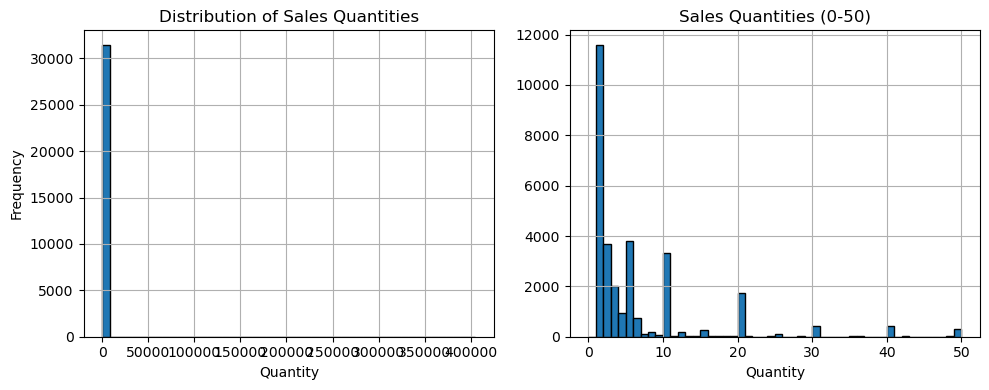

In [19]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sales['Quantity'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Sales Quantities')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
sales['Quantity'].hist(bins=50, range=(0,50), edgecolor='black')
plt.title('Sales Quantities (0-50)')
plt.xlabel('Quantity')
plt.tight_layout()
plt.show()

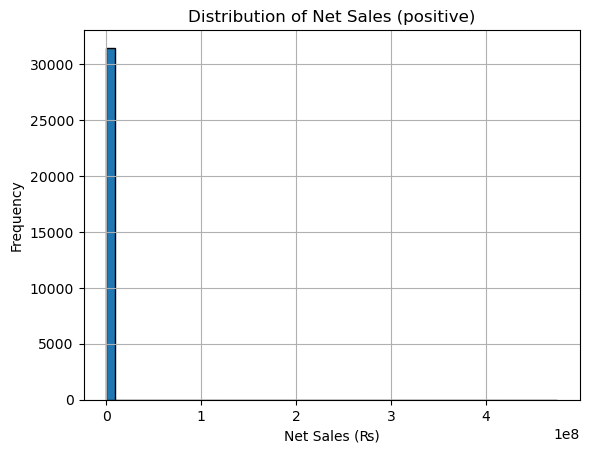

In [20]:
sales['Net Sales'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Net Sales (positive)')
plt.xlabel('Net Sales (₨)')
plt.ylabel('Frequency')
plt.show()

In [21]:
top_qty = df.groupby('Material')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_qty)

Material
571901NAE          46471
94702-00217        45720
571902NAE          32795
94701-00254        23486
1GC-E7632-01       16548
94702-00040        15766
571837NAE          14231
21C-E3440-01-00    11007
94702-00160        10995
90183-05042         9360
Name: Quantity, dtype: int64


In [22]:
top_sales = df.groupby('Material')['Net Sales'].sum().sort_values(ascending=False).head(10)
print(top_sales)

Material
571901NAE         75730683.80
571902NAE         55294934.87
571837NAE         26037590.29
94702-00217       21296417.40
KARBAT012V5A      12331124.40
PT300110-KTN       8028840.04
94701-00254        7988272.47
1GC-E7641-10       7908156.00
94702-00040        6960059.92
94568-K3128-00     6727421.95
Name: Net Sales, dtype: float64


In [23]:
monthly = df.groupby('Month_Num').agg({
    'Net Sales': 'sum',
    'Quantity': 'sum'
}).reset_index()
monthly = monthly.sort_values('Month_Num')
monthly['Month'] = monthly['Month_Num'].map({v:k for k,v in month_map.items()})

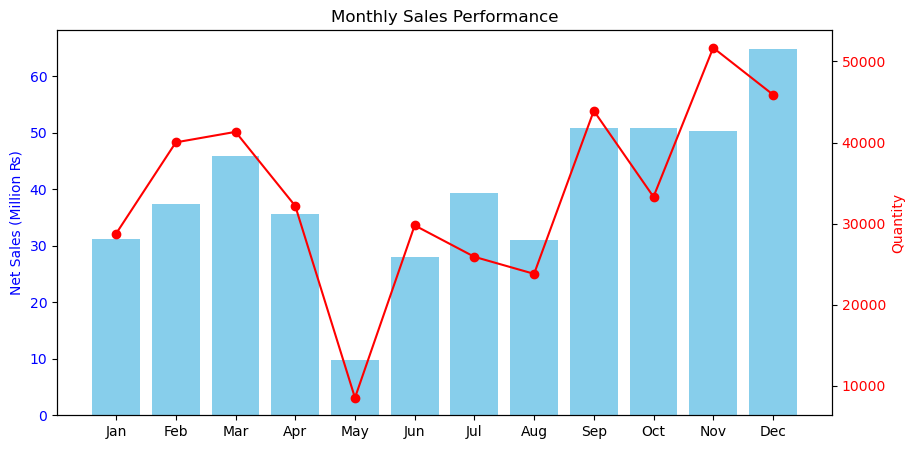

In [24]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(monthly['Month'], monthly['Net Sales']/1e6, color='skyblue', label='Net Sales (Million ₨)')
ax1.set_ylabel('Net Sales (Million ₨)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(monthly['Month'], monthly['Quantity'], color='red', marker='o', label='Quantity')
ax2.set_ylabel('Quantity', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Monthly Sales Performance')
plt.show()

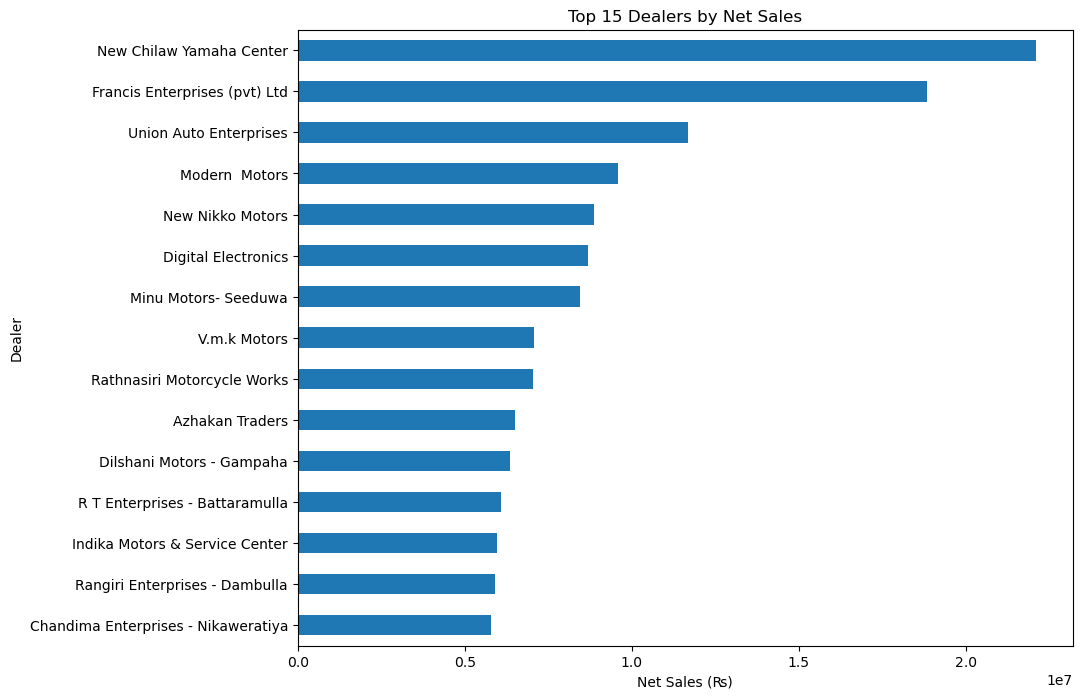

In [25]:
dealer_sales = df.groupby('Dealer')['Net Sales'].sum().sort_values(ascending=False).head(15)
dealer_sales.plot(kind='barh', figsize=(10,8))
plt.title('Top 15 Dealers by Net Sales')
plt.xlabel('Net Sales (₨)')
plt.gca().invert_yaxis()
plt.show()

In [26]:
dealer_returns = df.groupby('Dealer').apply(
    lambda x: (x['Quantity'] < 0).sum() / len(x) * 100
).sort_values(ascending=False).head(10)
print(dealer_returns)

Dealer
Bhagya Motors - Yatawatte      50.000000
Sripathi Motors - Rideegama    50.000000
RUWAN MOTORS-MADAMPE           50.000000
Dayananda Motors               50.000000
Dineth Motors                  40.000000
Ranasinghe Motors              33.333333
Agra Auto Enterprises          30.645161
Sudath Motorcycle Works        27.777778
Indunil Motors                 27.500000
Akash Motors                   25.000000
dtype: float64


C:\Users\Saminda\AppData\Local\Temp\ipykernel_5252\3364479427.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dealer_returns = df.groupby('Dealer').apply(


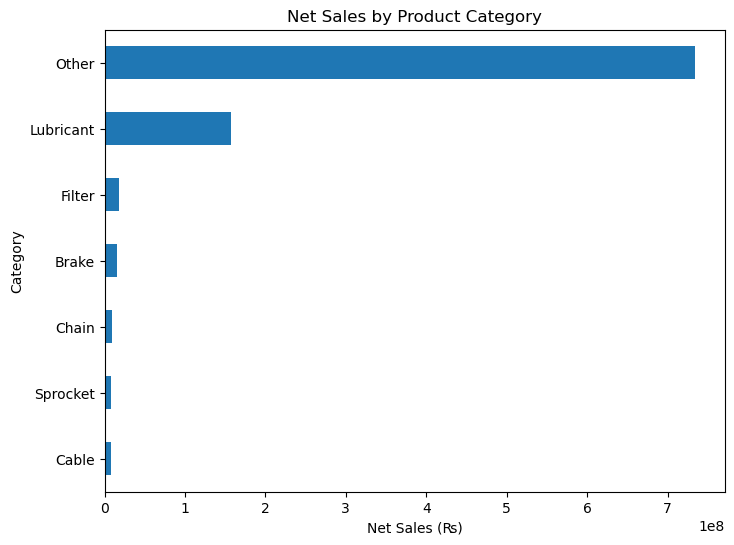

In [27]:
def categorize(desc):
    # make sure we can handle missing or non-string values
    if not isinstance(desc, str):
        return 'Other'
    desc = desc.upper()
    if 'YAMALUBE' in desc:
        return 'Lubricant'
    elif 'CHAIN' in desc:
        return 'Chain'
    elif 'BRAKE' in desc:
        return 'Brake'
    elif 'FILTER' in desc or 'ELEMENT' in desc:
        return 'Filter'
    elif 'SPROCKET' in desc:
        return 'Sprocket'
    elif 'CABLE' in desc:
        return 'Cable'
    else:
        return 'Other'

# apply categorization safely

# convert Description column to string before applying to avoid float NaNs
# or handle within function above

# adding category column now

df['Category'] = df['Description'].apply(categorize)
category_sales = df.groupby('Category')['Net Sales'].sum().sort_values()
category_sales.plot(kind='barh', figsize=(8,6))
plt.title('Net Sales by Product Category')
plt.xlabel('Net Sales (₨)')
plt.show()

In [28]:
sales['Unit Price'] = sales['Net Sales'] / sales['Quantity']
sales['Unit Price'].describe()

C:\Users\Saminda\AppData\Local\Temp\ipykernel_5252\646441269.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales['Unit Price'] = sales['Net Sales'] / sales['Quantity']


count     31459.000000
mean       2189.833415
std        3447.166702
min           1.142000
25%         629.235000
50%        1347.460000
75%        2262.710000
max      129527.540000
Name: Unit Price, dtype: float64

In [29]:
sales.nlargest(10, 'Unit Price')[['Description', 'Quantity', 'Net Sales', 'Unit Price']]

,Description,Quantity,Net Sales,Unit Price
1958,TOP COWLING YAMAHA 40 HP,1,129527.54,129527.540000
28605,FUEL PUMP COMP YAM XJ6SAP,2,254592.40,127296.200000
26390,"SHOCK ABSORBER ASSY, REAR XJ6SAP",3,307423.71,102474.570000
28559,CARBURETOR ASSY 1,1,83364.41,83364.410000
28583,METER ASSY,5,409099.57,81819.914000
18395,CARBURETOR ASSY 1 YAMAHA 40 HP,1,73413.27,73413.270000
22868,FUEL PUMP COMP.,3,202297.12,67432.373333
28620,"SHOCK ABSORBER ASSY, REAR XJ6SAP",4,254237.28,63559.320000
3405,"SHOCK ABSORBER ASSY, REAR XJ6SAP",6,381355.92,63559.320000
1834,C.D.I. UNIT ASSY,1,58430.08,58430.080000


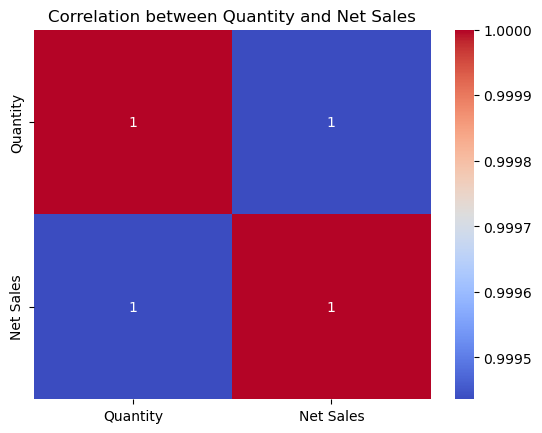

In [30]:
corr = df[['Quantity', 'Net Sales']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation between Quantity and Net Sales')
plt.show()

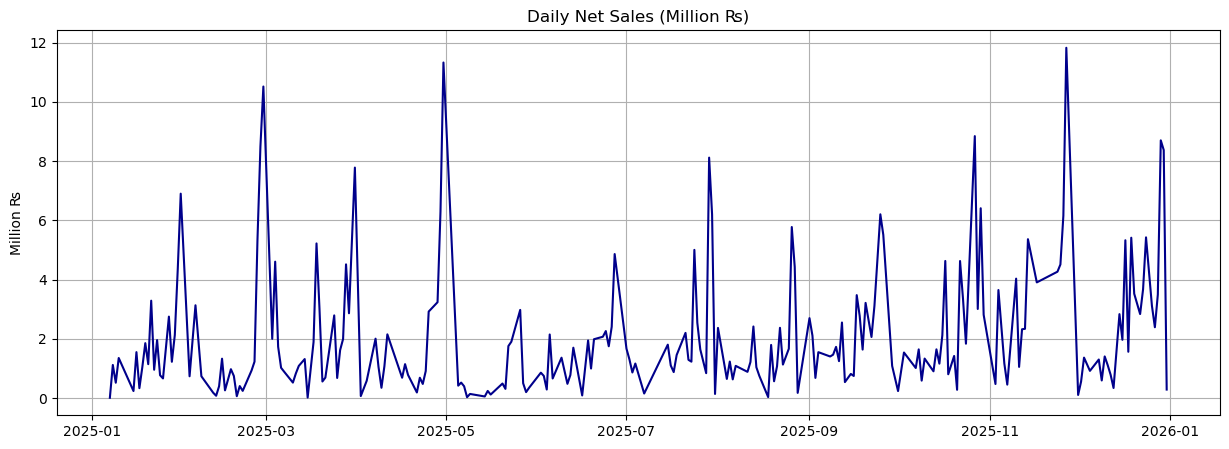

In [31]:
daily_sales = sales.groupby('Billing Date')['Net Sales'].sum().reset_index()
daily_sales.set_index('Billing Date', inplace=True)

plt.figure(figsize=(15,5))
plt.plot(daily_sales.index, daily_sales['Net Sales']/1e6, color='darkblue')
plt.title('Daily Net Sales (Million ₨)')
plt.ylabel('Million ₨')
plt.grid(True)
plt.show()

<Axes: title={'center': 'Monthly Net Sales'}, xlabel='Billing Date', ylabel='Million ₨'>

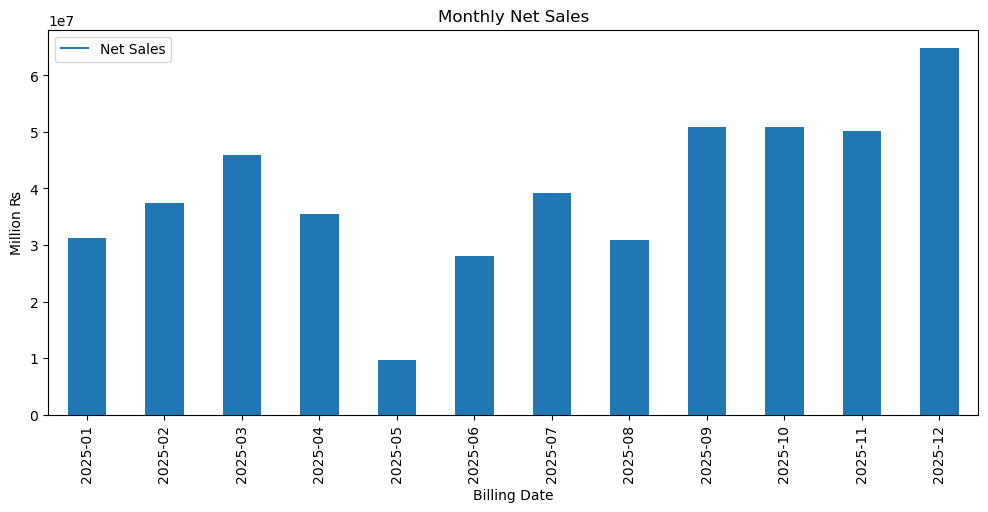

In [32]:
# Weekly sales
weekly_sales = daily_sales.resample('W').sum()
weekly_sales.plot(figsize=(15,4), title='Weekly Sales (Million ₨)', ylabel='Million ₨')

# Monthly sales (compute using billing date periods)
# `YearMonth` column wasn't defined earlier, so calculate on the fly
monthly_sales = df.groupby(df['Billing Date'].dt.to_period('M'))['Net Sales'].sum()
# convert period index to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales.plot(kind='bar', figsize=(12,5), title='Monthly Net Sales')

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

# build a clean monthly series directly from the original dataframe
monthly_series = df.groupby(df['Billing Date'].dt.to_period('M'))['Net Sales'].sum()

# convert period index back to timestamps and ensure start-of-month frequency
monthly_series = monthly_series.to_timestamp().asfreq('MS')

# do decomposition only if we have at least two full years (24 months)
if len(monthly_series) >= 24:
    decomposition = seasonal_decompose(monthly_series, model='additive', period=12)
    decomposition.plot()
    plt.show()
else:
    print(f"Not enough data for seasonal decomposition (need >=24 months, have {len(monthly_series)}).")

Not enough data for seasonal decomposition (need >=24 months, have 12).


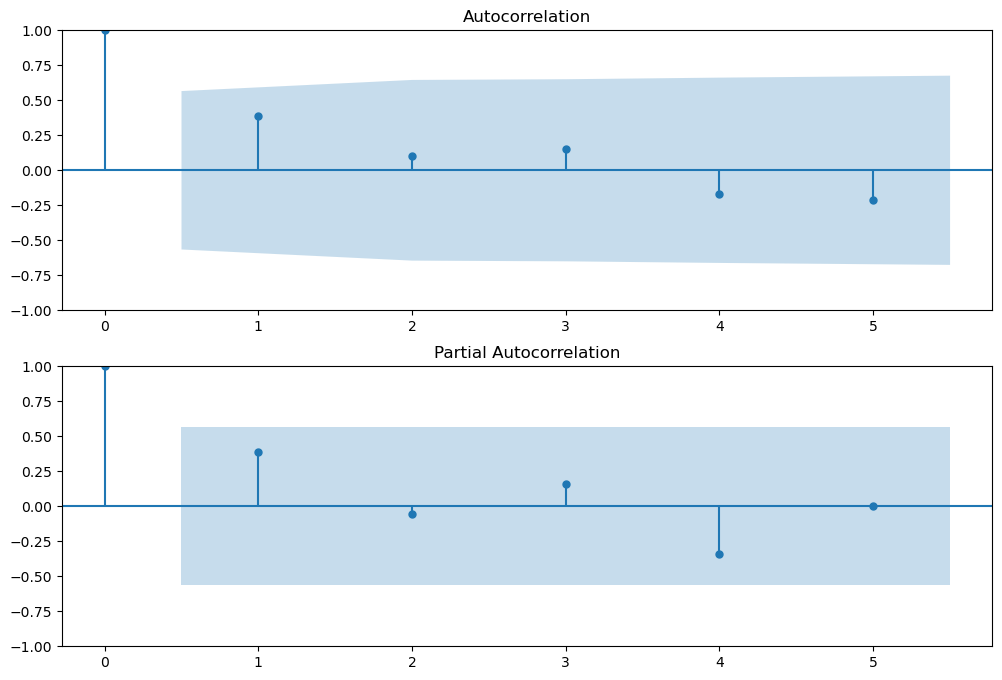

In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# choose lags based on sample size (<=50% rule)
max_lags = min(11, len(monthly_series.dropna())//2 - 1)
if max_lags < 1:
    print("Not enough data for ACF/PACF plots.")
else:
    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
    plot_acf(monthly_series.dropna(), lags=max_lags, ax=ax1)
    plot_pacf(monthly_series.dropna(), lags=max_lags, ax=ax2)
    plt.show()

In [35]:
# Last date in data
last_date = df['Billing Date'].max()

# compute base profile from positive-sales rows only to avoid confusion
sales_only = df[df['Quantity'] > 0]

dealer_profile = sales_only.groupby('Dealer Code').agg({
    'Net Sales': 'sum',   # total sales (exclude returns)
    'Quantity': 'sum',    # total units sold
    'Billing Date': lambda x: (last_date - x.max()).days,  # recency (sales only)
    'Dealer': 'first'   # keep name
}).rename(columns={'Net Sales':'TotalSales', 'Quantity':'TotalUnits', 'Billing Date':'Recency'})

# Add return metrics (using returns df defined earlier)
return_value = returns.groupby('Dealer Code')['Net Sales'].sum().abs()
dealer_profile['ReturnValue'] = return_value

# guard division by zero
dealer_profile['ReturnRate'] = (dealer_profile['ReturnValue'] /
                                (dealer_profile['TotalSales'] + dealer_profile['ReturnValue']).replace({0: np.nan}) ) * 100

dealer_profile.fillna(0, inplace=True)

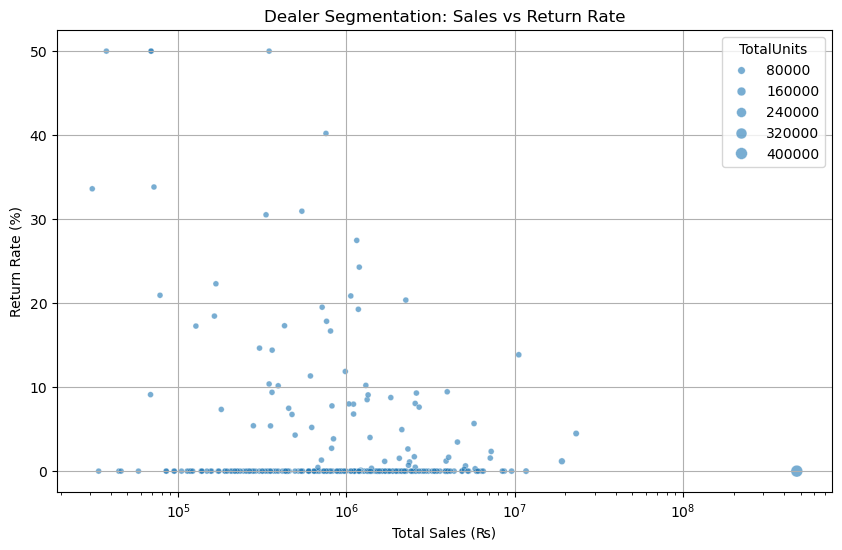

In [36]:
# Scatter: Sales vs Return Rate
plt.figure(figsize=(10,6))
sns.scatterplot(data=dealer_profile, x='TotalSales', y='ReturnRate', size='TotalUnits', alpha=0.6)
plt.title('Dealer Segmentation: Sales vs Return Rate')
plt.xlabel('Total Sales (₨)')
plt.ylabel('Return Rate (%)')
plt.xscale('log')   # because sales are highly skewed
plt.grid(True)
plt.show()

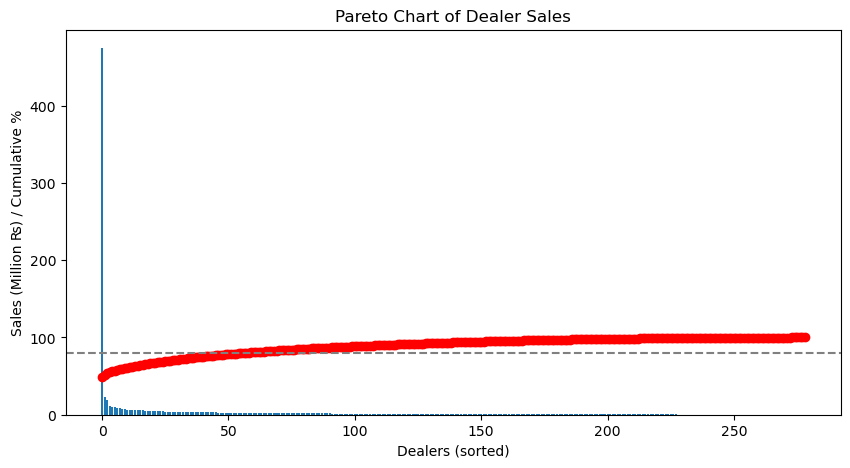

In [37]:
dealer_sorted = dealer_profile.sort_values('TotalSales', ascending=False)
dealer_sorted['CumulativeSales'] = dealer_sorted['TotalSales'].cumsum()
dealer_sorted['CumulativePercent'] = 100 * dealer_sorted['CumulativeSales'] / dealer_sorted['TotalSales'].sum()

plt.figure(figsize=(10,5))
plt.bar(range(len(dealer_sorted)), dealer_sorted['TotalSales']/1e6)
plt.plot(range(len(dealer_sorted)), dealer_sorted['CumulativePercent'], color='red', marker='o')
plt.axhline(80, linestyle='--', color='gray')
plt.title('Pareto Chart of Dealer Sales')
plt.xlabel('Dealers (sorted)')
plt.ylabel('Sales (Million ₨) / Cumulative %')
plt.show()

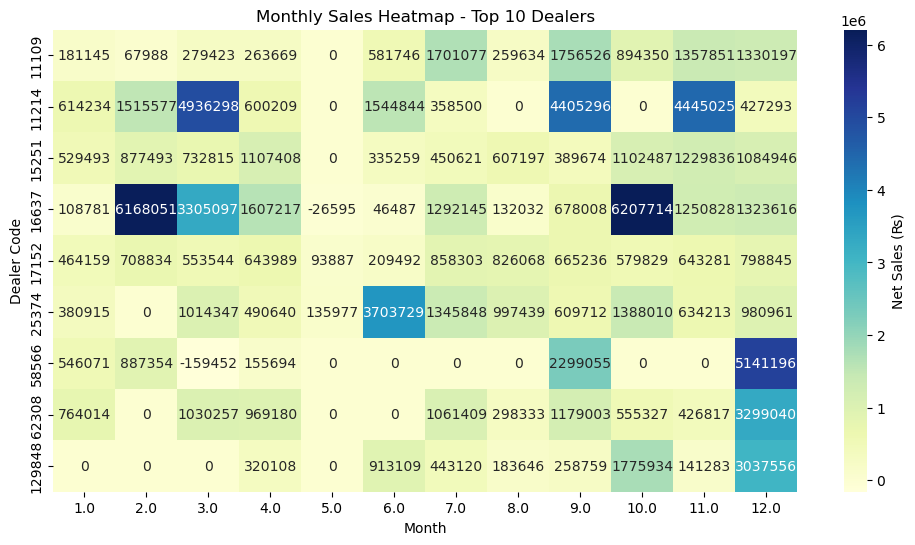

In [38]:
# Pivot table: Dealer vs Month, sum of Net Sales
top_dealers = dealer_profile.nlargest(10, 'TotalSales').index
dealer_month = df[df['Dealer Code'].isin(top_dealers)].pivot_table(
    index='Dealer Code', columns='Month_Num', values='Net Sales', aggfunc='sum', fill_value=0
)

plt.figure(figsize=(12,6))
sns.heatmap(dealer_month, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label':'Net Sales (₨)'})
plt.title('Monthly Sales Heatmap - Top 10 Dealers')
plt.xlabel('Month')
plt.ylabel('Dealer Code')
plt.show()

In [39]:
def detailed_category(desc):
    # guard against missing or non-string values
    if not isinstance(desc, str):
        return 'Other'
    desc = desc.upper()
    if 'YAMALUBE' in desc:
        return 'Lubricant'
    elif 'CHAIN' in desc:
        return 'Chain'
    elif 'BRAKE' in desc:
        return 'Brake'
    elif 'FILTER' in desc or 'ELEMENT' in desc:
        return 'Filter'
    elif 'SPROCKET' in desc:
        return 'Sprocket'
    elif 'CABLE' in desc:
        return 'Cable'
    elif 'PISTON' in desc:
        return 'Piston'
    elif 'VALVE' in desc:
        return 'Valve'
    elif 'BEARING' in desc:
        return 'Bearing'
    elif 'SEAL' in desc:
        return 'Seal'
    elif 'BATTERY' in desc:
        return 'Battery'
    elif 'TYRE' in desc:
        return 'Tyre'
    else:
        return 'Other'

# apply the more detailed categorization

df['Category'] = df['Description'].apply(detailed_category)

In [40]:
cat_stats = df.groupby('Category').agg({
    'Net Sales': 'sum',
    'Quantity': 'sum',
    'Material': 'count'   # transaction count
}).rename(columns={'Material':'Transactions'}).sort_values('Net Sales', ascending=False)

cat_stats['AvgPricePerUnit'] = cat_stats['Net Sales'] / cat_stats['Quantity']
cat_stats

,Net Sales,Quantity,Transactions,AvgPricePerUnit
Category,,,,
Other,6.686950e+08,633326,19780,1055.846411
Lubricant,1.570632e+08,93497,1749,1679.874316
Tyre,2.100757e+07,3702,772,5674.654773
Filter,1.775723e+07,27805,1215,638.634261
Brake,1.584879e+07,11998,1263,1320.952357
Battery,1.237180e+07,3555,353,3480.112776
Piston,1.145905e+07,2659,671,4309.534487
Seal,9.311987e+06,9043,1612,1029.745348
Chain,8.752639e+06,2263,428,3867.714799


In [41]:
# Positive sales by product
product_sales = sales.groupby('Material').agg({
    'Net Sales': 'sum',
    'Quantity': 'sum'
}).rename(columns={'Net Sales':'SalesValue', 'Quantity':'SalesQty'})

# Returns by product
product_returns = returns.groupby('Material').agg({
    'Net Sales': lambda x: x.abs().sum(),
    'Quantity': lambda x: x.abs().sum()
}).rename(columns={'Net Sales':'ReturnValue', 'Quantity':'ReturnQty'})

product_stats = product_sales.join(product_returns, how='outer').fillna(0)
product_stats['ReturnRate_Value'] = 100 * product_stats['ReturnValue'] / (product_stats['SalesValue'] + product_stats['ReturnValue'])
product_stats['ReturnRate_Qty'] = 100 * product_stats['ReturnQty'] / (product_stats['SalesQty'] + product_stats['ReturnQty'])
product_stats.sort_values('ReturnRate_Value', ascending=False, inplace=True)

# Top 10 products with highest return rate (by value)
product_stats[product_stats['SalesValue'] > 10000].head(10)

,SalesValue,SalesQty,ReturnValue,ReturnQty,ReturnRate_Value,ReturnRate_Qty
Material,,,,,,
5TS-H4314-00,26567.85,20.0,26567.85,20.0,50.000000,50.000000
6B8-14385-00,62786.57,5.0,62786.57,5.0,50.000000,50.000000
682-43311-07-8D,67830.51,2.0,67830.51,2.0,50.000000,50.000000
B97-E3907-01,26199.15,1.0,26199.15,1.0,50.000000,50.000000
21C-E4901-30,40290.25,1.0,40290.25,1.0,50.000000,50.000000
652-24471-10,93859.32,19.0,89923.77,18.0,48.929295,48.648649
663-44366-01,21820.33,8.0,16396.60,4.0,42.904022,33.333333
2SP-H3510-00-00,23478.80,2.0,16220.34,1.0,40.858165,33.333333
2GS-XF412-20-33,26752.11,3.0,17834.74,2.0,40.000000,40.000000


In [44]:
# ensure dataframe is loaded (kernel restart after package install clears variables)
if 'df' not in globals():
    df = pd.read_excel('Sales Report 2025.xlsx', sheet_name='Sheet1')
    df['Billing Date'] = pd.to_datetime(df['Billing Date'], format='%d.%m.%Y')
    df.rename(columns={'Sum of SlsVolQty': 'Quantity',
                       'Sum of Net Sales_1': 'Net Sales'}, inplace=True)

from mlxtend.frequent_patterns import apriori, association_rules

# Create a basket: each row is a transaction (Dealer + Date) with products as columns
basket_df = df.copy()
basket_df['TransactionID'] = basket_df['Dealer Code'].astype(str) + '_' + basket_df['Billing Date'].dt.date.astype(str)

# only consider positive-quantity rows for purchases
purchases = basket_df[basket_df['Quantity'] > 0]

# select top N materials by transaction count to keep dimensionality manageable
top_n = 100
trans_counts = purchases.groupby('Material')['TransactionID'].nunique()
common_materials = trans_counts.nlargest(top_n).index

# build the basket using only these common materials
basket = (
    purchases[purchases['Material'].isin(common_materials)]
        .groupby(['TransactionID', 'Material'])['Quantity']
        .sum().unstack(fill_value=0)
)

print('basket columns:', len(basket.columns))

# convert to boolean DataFrame (required by mlxtend)
basket = basket.astype(bool)

# if the number of transactions is still huge, take a random sample to keep memory manageable
max_trans = 10000
if basket.shape[0] > max_trans:
    basket = basket.sample(n=max_trans, random_state=42)

print('basket shape after sample', basket.shape)

# Run apriori with increased support, limit itemset size to 2 to control memory
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True, max_len=2)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.2)
rules.sort_values('lift', ascending=False).head(10)

basket columns: 100
basket shape after sample (3009, 100)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(571902NAE),(571901NAE),0.191093,0.245929,0.106680,0.558261,2.270009,1.0,0.059685,1.707051,0.691641,0.322938,0.414194,0.496022
2,(571901NAE),(571902NAE),0.245929,0.191093,0.106680,0.433784,2.270009,1.0,0.059685,1.428618,0.741937,0.322938,0.300023,0.496022
1,(571837NAE),(571901NAE),0.129279,0.245929,0.058824,0.455013,1.850181,1.0,0.027030,1.383649,0.527738,0.185924,0.277274,0.347101
0,(571901NAE),(571837NAE),0.245929,0.129279,0.058824,0.239189,1.850181,1.0,0.027030,1.144465,0.609375,0.185924,0.126229,0.347101


<Axes: title={'center': 'Return Rate (% of transactions) by Month'}, xlabel='Month_Num'>

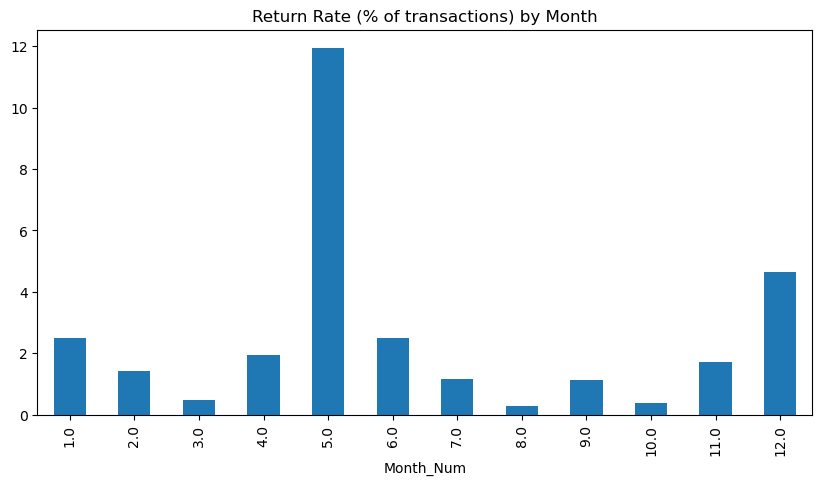

In [45]:
returns_by_month = returns.groupby('Month_Num')['Net Sales'].count()
sales_by_month = sales.groupby('Month_Num')['Net Sales'].count()
return_rate_month = (returns_by_month / sales_by_month) * 100

return_rate_month.plot(kind='bar', figsize=(10,5), title='Return Rate (% of transactions) by Month')

In [46]:
top_return_products = product_stats.nlargest(10, 'ReturnQty')[['ReturnQty', 'ReturnRate_Qty', 'SalesQty']]
top_return_products

,ReturnQty,ReturnRate_Qty,SalesQty
Material,,,
94701-00254,6063.0,17.025160,29549.0
571901NAE,995.0,2.053197,47466.0
94702-00217,650.0,1.382390,46370.0
21C-E3440-01,625.0,7.045429,8246.0
571902NAE,350.0,1.044932,33145.0
90183-05042,300.0,3.012048,9660.0
571837NAE,265.0,1.795271,14496.0
21C-F5364-00,164.0,2.991063,5319.0
1GC-E7632-01,144.0,0.855310,16692.0


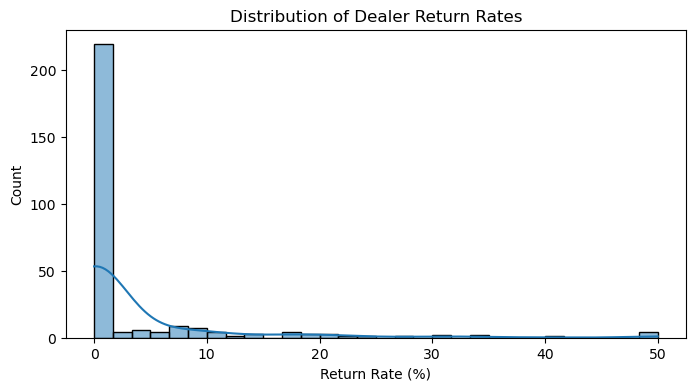

In [47]:
plt.figure(figsize=(8,4))
sns.histplot(dealer_profile['ReturnRate'], bins=30, kde=True)
plt.title('Distribution of Dealer Return Rates')
plt.xlabel('Return Rate (%)')
plt.show()

In [48]:
from scipy.stats import f_oneway

# Create list of monthly sales (positive only)
monthly_groups = [sales[sales['Month_Num']==m]['Net Sales'].values for m in range(1,13)]
f_stat, p_val = f_oneway(*monthly_groups)
print(f"ANOVA: F={f_stat:.2f}, p={p_val:.4f}")

ANOVA: F=21.95, p=0.0000


In [49]:
from scipy.stats import ttest_ind

top_dealers_ret = dealer_profile.nlargest(int(0.2*len(dealer_profile)), 'TotalSales')['ReturnRate']
bottom_dealers_ret = dealer_profile.nsmallest(int(0.2*len(dealer_profile)), 'TotalSales')['ReturnRate']

t_stat, p_val = ttest_ind(top_dealers_ret, bottom_dealers_ret, equal_var=False)
print(f"t-test: t={t_stat:.2f}, p={p_val:.4f}")

t-test: t=-2.55, p=0.0134


In [51]:
# Create dealer-month panel
dealer_month_panel = df.groupby(['Dealer Code', 'YearMonth']).agg({
    'Net Sales': 'sum',
    'Quantity': 'sum',
    'Material': 'count'   # transaction count
}).rename(columns={'Material':'TransCount'}).reset_index()

# Pivot for each dealer
dealer_pivot = dealer_month_panel.pivot(index='YearMonth', columns='Dealer Code', values='Net Sales')

KeyError: 'YearMonth'

In [53]:
# updated dealer-month panel with YearMonth creation
if 'YearMonth' not in df.columns:
    df['YearMonth'] = df['Billing Date'].dt.to_period('M')

dealer_month_panel = df.groupby(['Dealer Code', 'YearMonth']).agg({
    'Net Sales': 'sum',
    'Quantity': 'sum',
    'Material': 'count'
}).rename(columns={'Material':'TransCount'}).reset_index()

# convert period to string

dealer_month_panel['YearMonth'] = dealer_month_panel['YearMonth'].astype(str)

dealer_pivot = dealer_month_panel.pivot(index='YearMonth', columns='Dealer Code', values='Net Sales')